## Getting Started

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

### Task 1: Build a Reusable `bootstrap_ci` Function

In [2]:
def bootstrap_ci(data, stat_func=np.mean, n_boot=10_000, ci_level=0.95):
    """
    Returns (lower, upper) percentile bootstrap CI.

    Parameters
    ----------
    data      : array-like  — the sample to resample from
    stat_func : callable    — statistic to compute on each resample (default: np.mean)
    n_boot    : int         — number of bootstrap resamples
    ci_level  : float       — confidence level (e.g. 0.95 for 95 % CI)
    """
    data = np.asarray(data)
    n = len(data)

    # Step 1 & 2: draw n_boot resamples and compute stat on each
    boot_stats = np.array([
        stat_func(np.random.choice(data, size=n, replace=True))
        for _ in range(n_boot)
    ])

    # Step 3: extract percentile bounds
    alpha = 1 - ci_level
    lower = np.percentile(boot_stats, 100 * alpha / 2) 
    upper = np.percentile(boot_stats, 100 * (1 - alpha / 2))

    # Step 4: return the interval
    return lower, upper 

In [3]:
# Validation: 95 % CI of mean for integers 1–100 should be ≈ (40, 60)
validation_data = np.arange(1, 101)
lo, hi = bootstrap_ci(validation_data)
print(f"Validation 95 % CI for mean of 1–100: ({lo:.2f}, {hi:.2f})")
print("Expected: roughly (40, 60)  ✓" if 38 < lo < 46 and 54 < hi < 62 else "⚠️ check function")
# Output: Validation 95 % CI for mean of 1–100: (44.80, 56.10)  ✓

Validation 95 % CI for mean of 1–100: (44.80, 56.10)
Expected: roughly (40, 60)  ✓


### Task 2: Apply Bootstrap CIs to Real Data

In [4]:
np.random.seed(42)
N = 500

# Continuous: log-normal response times (right-skewed, mean ≈ 350 ms)
response_time_ms = np.random.lognormal(mean=5.8, sigma=0.6, size=N)

# Binary: ~30 % conversion rate
converted = np.random.binomial(n=1, p=0.30, size=N)

df = pd.DataFrame({
    'response_time_ms': response_time_ms,
    'converted': converted
})

print(df.shape)
df.describe() 

(500, 2)


,response_time_ms,converted
count,500.000000,500.000000
mean,397.332927,0.298000
std,283.565260,0.457838
min,47.239934,0.000000
25%,216.982291,0.000000
50%,332.845459,0.000000
75%,483.994909,1.000000
max,3333.036050,1.000000


C:\Users\User\AppData\Local\Temp\ipykernel_16752\1193831861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='converted', data=df, ax=axes[1],


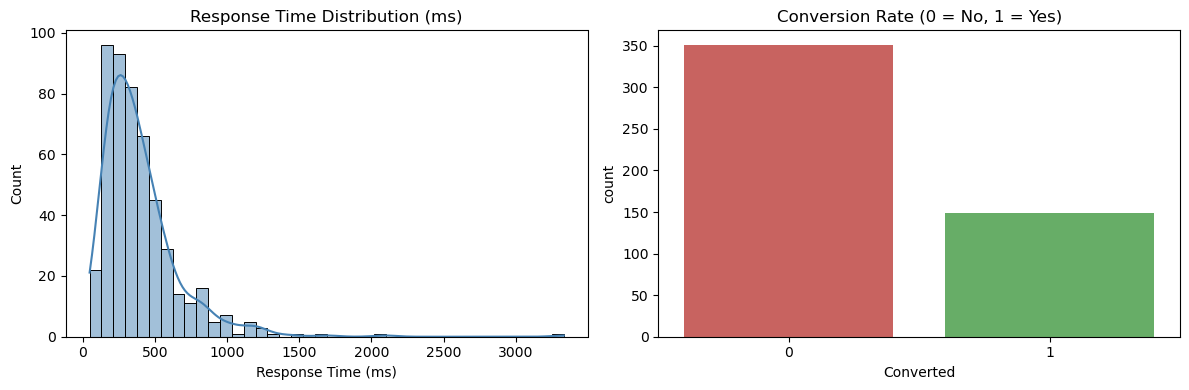

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['response_time_ms'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Response Time Distribution (ms)')
axes[0].set_xlabel('Response Time (ms)')

sns.countplot(x='converted', data=df, ax=axes[1],
              palette=['#d9534f', '#5cb85c'])
axes[1].set_title('Conversion Rate (0 = No, 1 = Yes)')
axes[1].set_xlabel('Converted')

plt.tight_layout()
plt.show()

In [6]:
np.random.seed(42)

ci_mean   = bootstrap_ci(df['response_time_ms'], stat_func=np.mean)
ci_median = bootstrap_ci(df['response_time_ms'], stat_func=np.median)
ci_prop   = bootstrap_ci(df['converted'],        stat_func=np.mean)

summary = pd.DataFrame({
    'Statistic': ['Mean (response_time_ms)',
                   'Median (response_time_ms)',
                   'Proportion (converted)'],
    'Point Estimate': [
        round(np.mean(df['response_time_ms']), 4),
        round(np.median(df['response_time_ms']), 4),
        round(np.mean(df['converted']), 4)
    ],
    'Bootstrap Lower': [round(ci_mean[0], 4),
                         round(ci_median[0], 4),
                         round(ci_prop[0], 4)],
    'Bootstrap Upper': [round(ci_mean[1], 4),
                         round(ci_median[1], 4),
                         round(ci_prop[1], 4)],
})

print("95 % Bootstrap Confidence Intervals")
summary 

95 % Bootstrap Confidence Intervals


,Statistic,Point Estimate,Bootstrap Lower,Bootstrap Upper
0,Mean (response_time_ms),397.3329,373.6398,422.9310
1,Median (response_time_ms),332.8455,313.1017,350.2355
2,Proportion (converted),0.2980,0.2580,0.3380


### Task 3: Compare Bootstrap CIs with Normal-Approximation CIs 

In [7]:
n = len(df)

# 1. Mean CI via Student t-interval
x_bar  = np.mean(df['response_time_ms'])
se_mean = st.sem(df['response_time_ms'])
t_lo, t_hi = st.t.interval(0.95, df=n - 1, loc=x_bar, scale=se_mean)

# 2. Proportion CI via Wald interval  p̂ ± 1.96 × sqrt(p̂(1-p̂)/n)
p_hat  = np.mean(df['converted'])
z      = 1.96
margin = z * np.sqrt(p_hat * (1 - p_hat) / n)
w_lo, w_hi = p_hat - margin, p_hat + margin

# Comparison table
comparison = pd.DataFrame({
    'Statistic':       ['Mean (response_time_ms)', 'Proportion (converted)'],
    'Bootstrap Lower': [round(ci_mean[0], 4),      round(ci_prop[0], 4)],
    'Bootstrap Upper': [round(ci_mean[1], 4),      round(ci_prop[1], 4)],
    'Normal Lower':    [round(t_lo, 4),             round(w_lo, 4)],
    'Normal Upper':    [round(t_hi, 4),             round(w_hi, 4)],
})
print("Bootstrap vs Normal-Approximation 95 % CIs")
comparison 

Bootstrap vs Normal-Approximation 95 % CIs


,Statistic,Bootstrap Lower,Bootstrap Upper,Normal Lower,Normal Upper
0,Mean (response_time_ms),373.6398,422.931,372.4174,422.2485
1,Proportion (converted),0.2580,0.338,0.2579,0.3381


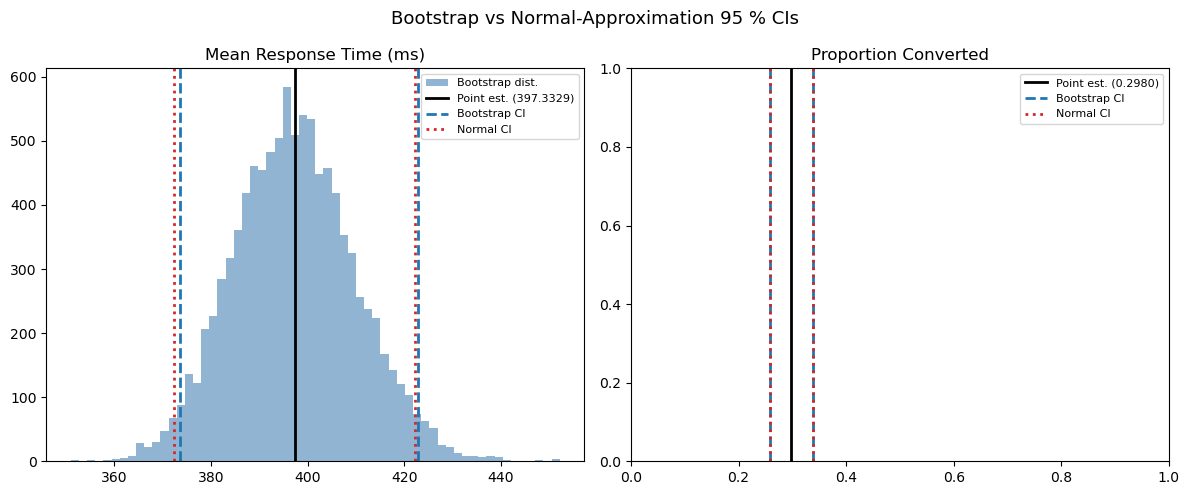

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, title, point, boot, normal, col in [
    (axes[0], 'Mean Response Time (ms)', x_bar, ci_mean, (t_lo, t_hi), df['response_time_ms']),
    (axes[1], 'Proportion Converted',    p_hat, ci_prop, (w_lo, w_hi), None)
]:
    if col is not None:
        np.random.seed(42)
        boot_dist = [np.mean(np.random.choice(col, size=len(col), replace=True))
                     for _ in range(10_000)]
        ax.hist(boot_dist, bins=60, color='steelblue', alpha=0.6, label='Bootstrap dist.')

    ax.axvline(point,     color='black',   lw=2, ls='-',  label=f'Point est. ({point:.4f})')
    ax.axvline(boot[0],  color='tab:blue',lw=2, ls='--', label='Bootstrap CI')
    ax.axvline(boot[1],  color='tab:blue',lw=2, ls='--')
    ax.axvline(normal[0],color='tab:red', lw=2, ls=':',  label='Normal CI')
    ax.axvline(normal[1],color='tab:red', lw=2, ls=':')
    ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle('Bootstrap vs Normal-Approximation 95 % CIs', fontsize=13)
plt.tight_layout()
plt.show() 